In [1]:
import sys 
sys.path.insert(0,'../Modules/')
import numpy as np 
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp
from index_set import index_set
from families import JacobiPolynomials

def cond_G(hc_param, induced):

    ### Approximation space parameters
    max_poly_degree =   10               # Maximum univariate degree of polynomials used to define operator basis 
    input_mode_truncation = 20           # Truncated Dimension of Input Function Space 
    jacobi_params = [[a**2, a**2]for a in range(input_mode_truncation)]

    ### Build Index Set
    weights = np.linspace(1, 0.01, input_mode_truncation)
    idx_set = index_set(input_mode_truncation, hc_param, max_index=max_poly_degree, weights=weights, max_size=5000, type="hc")    
    N = idx_set.shape[0]
    M = int(N * np.log(N))

    ### Generate Input Samples:
    if induced:
        input_samples = input_samples = Jacobi_Tensor_Induced_Sampling(M, idx_set, jacobi_params, max_poly_degree)
    else: 
        input_samples = jacobi_tensor_samp(jacobi_params, M)
    
    ### Build Vandermonde Matrix:
    JacobiPolys = [JacobiPolynomials(*params) for params in jacobi_params]
    V = np.ones((M,N))
    for n in range(N):
        for j in range(input_mode_truncation):
            deg = int(idx_set[n, j])
            if deg != 0:
                poly_eval = JacobiPolys[j].eval_1d(input_samples[:, j], deg)[:, 0]
                V[:, n] *= poly_eval

    ### Weight if induced: 
    if induced == True: 
        weights = N / np.sum(V**2, axis=1)
    elif induced == False: 
        weights = np.ones(M)
    
    ### Form the diagonal scaling matrix D = sqrt(weights/M) (shape: (M, 1)).
    D = np.sqrt(weights / M)[:, np.newaxis]
    
    ### Weighted Vandermonde matrix: A = D * V.
    A = D * V
    return N, np.linalg.cond(A)**2

# Get condition number / (effective) dimension 
runs = 3
Hc = np.arange(10,70,10)
Dims = np.zeros(Hc.shape[0])
C_Ind = np.zeros((Hc.shape[0], runs))
C_Std = np.zeros((Hc.shape[0], runs))
for h in range(Hc.shape[0]):
    for r in range(runs):
        Dims[h],C_Ind[h,r] = cond_G(Hc[h], True)
        Dims[h], C_Std[h,r] = cond_G(Hc[h], False)

np.save('Data/Condition_Ind.npy', C_Ind)
np.save('Data/Condition_Std.npy', C_Std)
np.save("Data/Condition_Dims.npy", Dims)

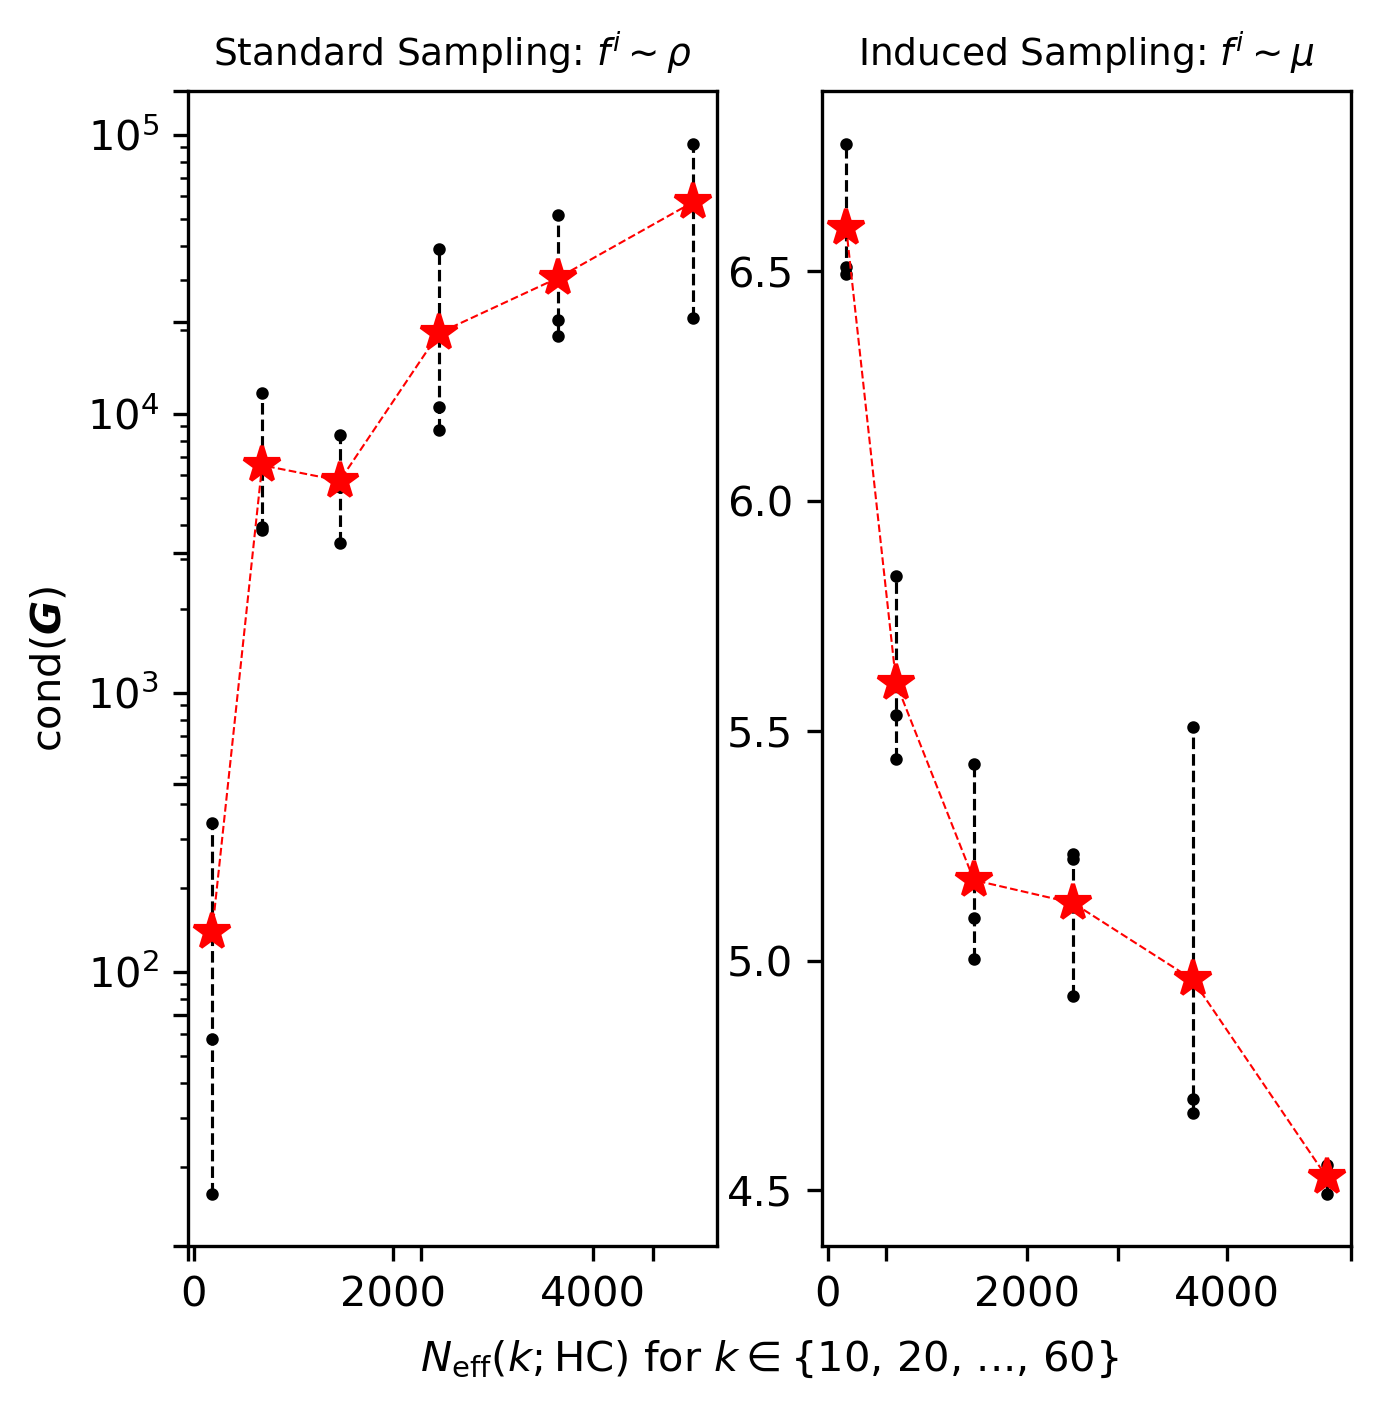

In [2]:
import matplotlib as mpl
import numpy as np
mpl.rcParams['figure.dpi'] = 300
import matplotlib.pyplot as plt 
import seaborn as sns 

runs = 3
Hc = np.arange(10,70,10)

C_Ind = np.load("Data/Condition_Ind.npy")
C_Std = np.load("Data/Condition_Std.npy")
Dims = np.load("Data/Condition_Dims.npy")

plt.figure(figsize=(5,5))
plt.box(False)
plt.xlabel("\n" + r"$N_{\mathrm{eff}}(k; \mathrm{HC})$ for $ k\in $" +f"{{{Hc[0]}, {Hc[1]}, ..., {Hc[-1]}}}")
ax = plt.gca()
ax.set_axis_off
ax.set_yticklabels([])
ax.set_xticklabels([])

plt.subplot(121)
plt.title(r"Standard Sampling: $f^i\sim \rho$", fontsize = 9)
ax = plt.gca()
plt.yscale('log')
for h in range(Hc.shape[0]):
    plt.plot(Dims[h]*np.ones(10), np.linspace(np.min(C_Std[h,:]), np.max(C_Std[h,:]),10),'k--',linewidth = 0.75)
    for r in range(runs):
        plt.plot(Dims[h],C_Std[h,r],'ko',markersize = 2)
plt.plot(Dims, np.mean(C_Std,axis=1), 'r*--',markersize = 9, linewidth = 0.5)
plt.ylabel(r"$\mathrm{cond}(\boldsymbol{G})$")

plt.subplot(122)
plt.title(r"Induced Sampling: $f^i\sim \mu$", fontsize = 9)
for h in range(Hc.shape[0]):
    plt.plot(Dims[h]*np.ones(10), np.linspace(np.min(C_Ind[h,:]), np.max(C_Ind[h,:]),10),'k--',linewidth = 0.75)
    for r in range(runs):
        plt.plot(Dims[h],C_Ind[h,r],'ko',markersize = 2)
plt.plot(Dims, np.mean(C_Ind,axis=1), 'r*--',markersize = 9, linewidth = 0.5)
plt.savefig("Plots/vB_CondNum.pdf")
plt.show()

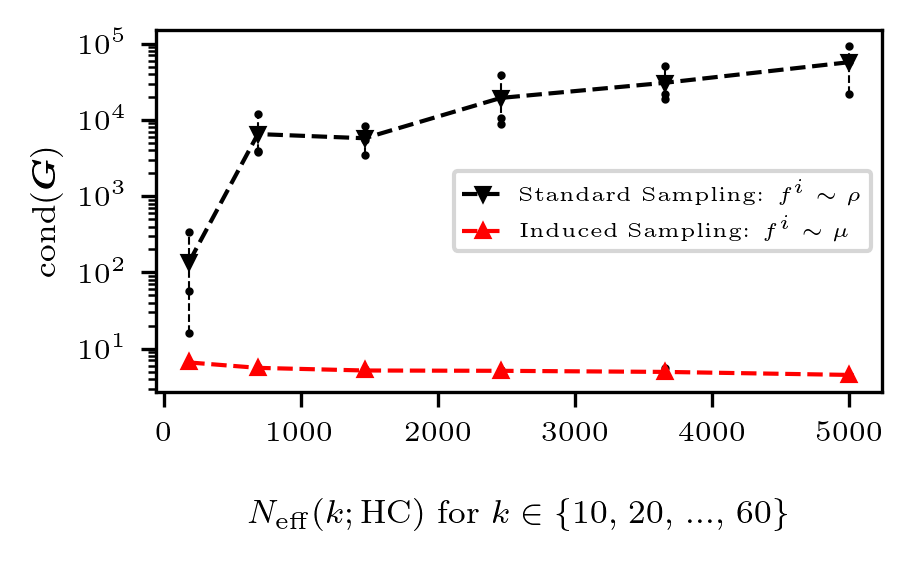

In [9]:
import matplotlib as mpl
import numpy as np
mpl.rcParams['figure.dpi'] = 300
import matplotlib.pyplot as plt 
import seaborn as sns 


import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 0.5
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base -2        
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 3
linewidth_large = 1 


runs = 3
Hc = np.arange(10,70,10)

C_Ind = np.load("Data/Condition_Ind.npy")
C_Std = np.load("Data/Condition_Std.npy")
Dims = np.load("Data/Condition_Dims.npy")

fig, ax = plt.subplots(figsize = (fig_width,fig_height), layout = 'constrained')
ax.set_xlabel("\n" + r"$N_{\mathrm{eff}}(k; \mathrm{HC})$ for $ k\in \{$" +f"{{{Hc[0]}, {Hc[1]}, ..., {Hc[-1]}}}" + r"$\}$")
ax = plt.gca()
ax.set_yscale('log')
for h in range(Hc.shape[0]):
    ax.plot(Dims[h]*np.ones(10), np.linspace(np.min(C_Std[h,:]), np.max(C_Std[h,:]),10),'k--',linewidth = linewidth_small)
    for r in range(runs):
        ax.plot(Dims[h],C_Std[h,r],'ko',markersize = markersize_small)
ax.plot(Dims, np.mean(C_Std,axis=1), 'kv--',markersize = markersize_large, linewidth = linewidth_large,label = r"Standard Sampling: $f^i\sim \rho$")
ax.set_ylabel(r"$\mathrm{cond}(\boldsymbol{G})$")


for h in range(Hc.shape[0]):
    ax.plot(Dims[h]*np.ones(10), np.linspace(np.min(C_Ind[h,:]), np.max(C_Ind[h,:]),10),'k--',linewidth = linewidth_small)
    for r in range(runs):
        ax.plot(Dims[h],C_Ind[h,r],'ko',markersize = markersize_small)
ax.plot(Dims, np.mean(C_Ind,axis=1), 'r^--',markersize = markersize_large, linewidth = linewidth_large, label = r"Induced Sampling: $f^i\sim \mu$")
ax.legend(loc = 'best')
plt.savefig("Plots/vB_CondNum.pdf",bbox_inches = 'tight')
plt.show()